In [2]:
import pandas as pd
import numpy as np
import importlib

import plotly.express as px
import matplotlib.pyplot as plt

import irina.utility_functions as uf

In [3]:
start_year = 1970
end_year = 2023
year_list = range(1970, 2023)
mode = "collaborative"

In [4]:
# df_prob_yearly_list = []
#
# for year_loop in year_list:
#     df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year_loop}.csv", index_col=0)
#     df_prob_yearly_list.append(
#         df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop)
#     )
#
# df_prob_yearly = pd.concat(df_prob_yearly_list)

In [38]:
country = "ID"
df_country = (
    pd.read_csv(uf.PATH+f"df_prob_yearly.csv")
    .query("country == @country and mode==@mode")
    .drop(["country", "mode"], axis=1)
    .set_index("year")
)
# df_country

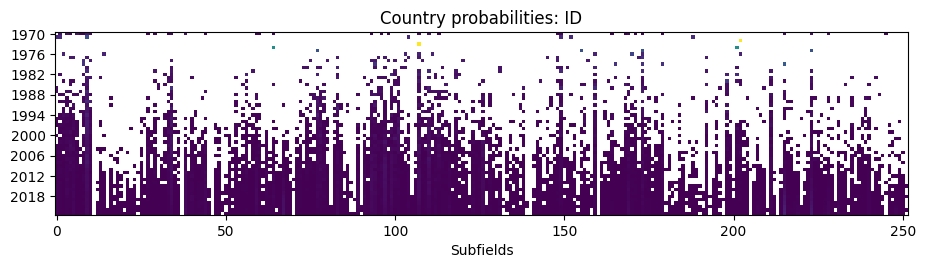

In [39]:
fig = plt.subplots(figsize=(11, 6))
plt.imshow(df_country.values)
plt.xticks(ticks=None)
plt.xlabel("Subfields")
idx = np.arange(0, len(year_list), 6)
plt.yticks(ticks=idx, labels=np.array(year_list)[idx])
plt.title(f"Country probabilities: {country}")
plt.show()

In [40]:
df_dist = uf.get_jaccard_distances(df_country)

In [41]:
uf.plotly_heatmap(df_dist, x_labels=df_dist.index, y_labels=df_dist.index, colorscale=False, line_height=10,
                  title=f"Distances yearly: {uf.id2name_country[country]}", z_min=0, z_max=1)